# 0 · Análisis Exploratorio de Datos (EDA)
**Datasets:** Kaggle OCT 
**Tarea:** Segmentación de capas retinales en imágenes OCT  

Este notebook puede ejecutarse tanto como `.ipynb` (Jupyter / Kaggle / Colab)  
como script Python (`python 0_analisis.py`). La cabecera de entorno detecta  
automáticamente el contexto y ajusta rutas y visualización.

In [1]:
# ============================================================
#  CABECERA DE ENTORNO  (Notebook / Script / Kaggle / Colab)
# ============================================================
import sys, os
from pathlib import Path

# --- Detectar entorno ---
def _detect_env() -> str:
    """Devuelve 'colab' | 'kaggle' | 'notebook' | 'script'.
    IMPORTANTE: Kaggle se chequea primero porque tiene google.colab
    instalado pero sin soporte real para drive.mount."""
    # 1) Kaggle primero (tiene google.colab pero sin drive.mount real)
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
        return 'kaggle'
    # 2) Colab real
    try:
        import google.colab  # noqa: F401
        return 'colab'
    except ImportError:
        pass
    try:
        get_ipython()  # noqa: F821
        return 'notebook'
    except NameError:
        return 'script'

ENV = _detect_env()
IS_NOTEBOOK = ENV in ('colab', 'kaggle', 'notebook')
print(f'[ENV] Entorno detectado: {ENV}')

# --- Rutas raíz según entorno ---
if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT_DIR = Path('/content/drive/MyDrive/oct-retina-segmentation')
elif ENV == 'kaggle':
    ROOT_DIR = Path('/kaggle/working')
else:  # notebook local o script
    # Sube dos niveles desde este archivo para llegar a la raíz del proyecto
    _here = Path(globals().get('__file__', './')).resolve()
    ROOT_DIR = _here.parents[1] if _here.suffix == '.py' else _here.parent

DATA_DIR = ROOT_DIR / 'TP_vision_por_computadora_2'/'data'
print(f'[ENV] ROOT_DIR = {ROOT_DIR}')
print(f'[ENV] DATA_DIR = {DATA_DIR}')

# Agregar src al path para importar review_data
SRC_DIR = ROOT_DIR / 'src'
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

[ENV] Entorno detectado: notebook
[ENV] ROOT_DIR = C:\Users\User\oct-retina-segmentation\OCT
[ENV] DATA_DIR = C:\Users\User\oct-retina-segmentation\OCT\data


In [2]:
# ============================================================
#  IMPORTS
# ============================================================
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import cv2
from PIL import Image
from scipy.io import loadmat

try:
    import pyzipper
except ImportError:
    pyzipper = None

# Paleta de colores para capas (hasta 10 capas)
LAYER_COLORS = ['#e6194b','#3cb44b','#4363d8','#f58231',
                '#911eb4','#42d4f4','#f032e6','#bfef45','#fabed4','#469990']

print('[OK] Imports completados.')

[OK] Imports completados.


In [9]:
# ============================================================
#  RUTAS DE DATOS (centralizado)
# ============================================================
# --- Rutas raíz según entorno ---
if ENV == 'kaggle':
    KAGGLE_IMAGES_PATH = Path("C:/Users/User/oct-retina-segmentation/OCT/data/Data_Kaggle/resized_images.npy")
    KAGGLE_LABELS_PATH = Path("C:/Users/User/oct-retina-segmentation/OCT/data/Data_Kaggle/resized_labeledimages.npy")
else:  # notebook local o script
    KAGGLE_IMAGES_PATH = DATA_DIR / 'Data_Kaggle' / 'resized_images.npy'
    KAGGLE_LABELS_PATH = DATA_DIR / 'Data_Kaggle' / 'resized_labeledimages.npy'

print('[OK] Rutas configuradas.')

[OK] Rutas configuradas.


In [10]:
# ============================================================
#  HELPERS DE DESCARGA
# ============================================================
import zipfile

def _download_gdrive(file_id: str, dest: Path) -> bool:
    """Descarga desde Google Drive con gdown."""
    try:
        import gdown
        gdown.download(f'https://drive.google.com/uc?id={file_id}', str(dest), quiet=False)
        return dest.exists()
    except Exception as e:
        print(f'[ERROR] gdown: {e}')
        return False

# Descarga automática si los datos no están presentes en caso que no se ejecute en kaggle.
# Kaggle no permite acceso libre a internet.
if KAGGLE_IMAGES_PATH.exists():
    print('[KAGGLE-imgs] Ya disponible.')
else:
    print('[KAGGLE-imgs] Error no disponible.')
if KAGGLE_LABELS_PATH.exists():
        print('[KAGGLE-labels] Ya disponible.')
else:
    print('[KAGGLE-labels] Error no disponible.')
    

[KAGGLE-imgs] Ya disponible.
[KAGGLE-labels] Ya disponible.


---
## 1 · Dataset Kaggle OCT
Formato: `.npy` con imágenes redimensionadas y máscaras de clase por píxel.

In [11]:
# --- Carga y estadísticas ---
assert KAGGLE_IMAGES_PATH.exists(), f'No encontrado: {KAGGLE_IMAGES_PATH}'

kag_imgs  = np.load(KAGGLE_IMAGES_PATH)
kag_masks = np.load(KAGGLE_LABELS_PATH)

print('=== KAGGLE ===')
print(f'  Imágenes  shape : {kag_imgs.shape}   dtype: {kag_imgs.dtype}')
print(f'  Máscaras  shape : {kag_masks.shape}  dtype: {kag_masks.dtype}')
print(f'  N muestras      : {kag_imgs.shape[0]}')
print(f'  Resolución      : {kag_imgs.shape[1]} x {kag_imgs.shape[2]} px')
print(f'  Intensidad img  : min={kag_imgs.min():.1f}  max={kag_imgs.max():.1f}  mean={kag_imgs.mean():.1f}')
print(f'  Clases únicas   : {np.unique(kag_masks)}')
n_classes_kag = len(np.unique(kag_masks))
print(f'  Nº clases       : {n_classes_kag}')

=== KAGGLE ===
  Imágenes  shape : (220, 216, 500)   dtype: int64
  Máscaras  shape : (220, 216, 500)  dtype: float64
  N muestras      : 220
  Resolución      : 216 x 500 px
  Intensidad img  : min=0.0  max=255.0  mean=60.4
  Clases únicas   : [0. 1. 2. 3. 4. 5. 6. 7.]
  Nº clases       : 8


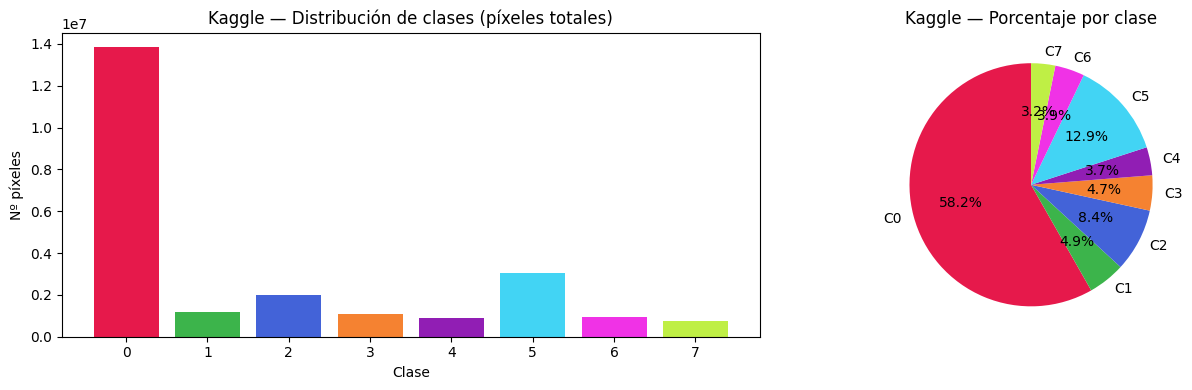

[KAGGLE] Gráfico de distribución de clases guardado.


In [12]:
# --- Distribución de clases en Kaggle ---
class_counts = np.bincount(kag_masks.flatten().astype(np.int64))
class_pct    = class_counts / class_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(len(class_counts)), class_counts, color=LAYER_COLORS[:len(class_counts)])
axes[0].set_title('Kaggle — Distribución de clases (píxeles totales)')
axes[0].set_xlabel('Clase'); axes[0].set_ylabel('Nº píxeles')

axes[1].pie(class_pct, labels=[f'C{i}' for i in range(len(class_pct))],
            colors=LAYER_COLORS[:len(class_pct)], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Kaggle — Porcentaje por clase')

plt.tight_layout()
plt.savefig('kaggle_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('[KAGGLE] Gráfico de distribución de clases guardado.')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# KAGGLE — máscaras pixel-wise (.npy)
# ============================================================
kag_masks = np.load(KAGGLE_LABELS_PATH)  # shape (N, H, W)

# Capas presentes en cada imagen (excluye clase 0 = fondo)
layers_per_image_kag = []
for i in range(kag_masks.shape[0]):
    clases = np.unique(kag_masks[i])
    n_capas = len(clases[clases > 0])  # excluye fondo (clase 0)
    layers_per_image_kag.append(n_capas)

layers_per_image_kag = np.array(layers_per_image_kag)

print("=== KAGGLE ===")
print(f"  Capas mín / máx : {layers_per_image_kag.min()} / {layers_per_image_kag.max()}")
print(f"  Capas promedio  : {layers_per_image_kag.mean():.2f}")
print(f"  Distribución    : {np.bincount(layers_per_image_kag)}")
valores, conteos = np.unique(layers_per_image_kag, return_counts=True)
for v, c in zip(valores, conteos):
    print(f"  {c} imágenes tienen {v} capas")

In [ ]:
from collections import Counter

# Contar cuántas imágenes tienen cada número de capas
layer_counts = Counter(layers_per_image_kag)

# Ordenar de más a menos frecuente (equivalente a most_common)
top_layers = layer_counts.most_common()  # sin límite porque son pocos valores

labels = [f"{n} capas" for n, _ in top_layers]
values = [count for _, count in top_layers]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, values, color="#4363d8", edgecolor="white")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.5,
        str(int(y)),
        ha="center", va="bottom", fontsize=10
    )

plt.title("Kaggle — Distribución de capas por imagen")
plt.ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.show()

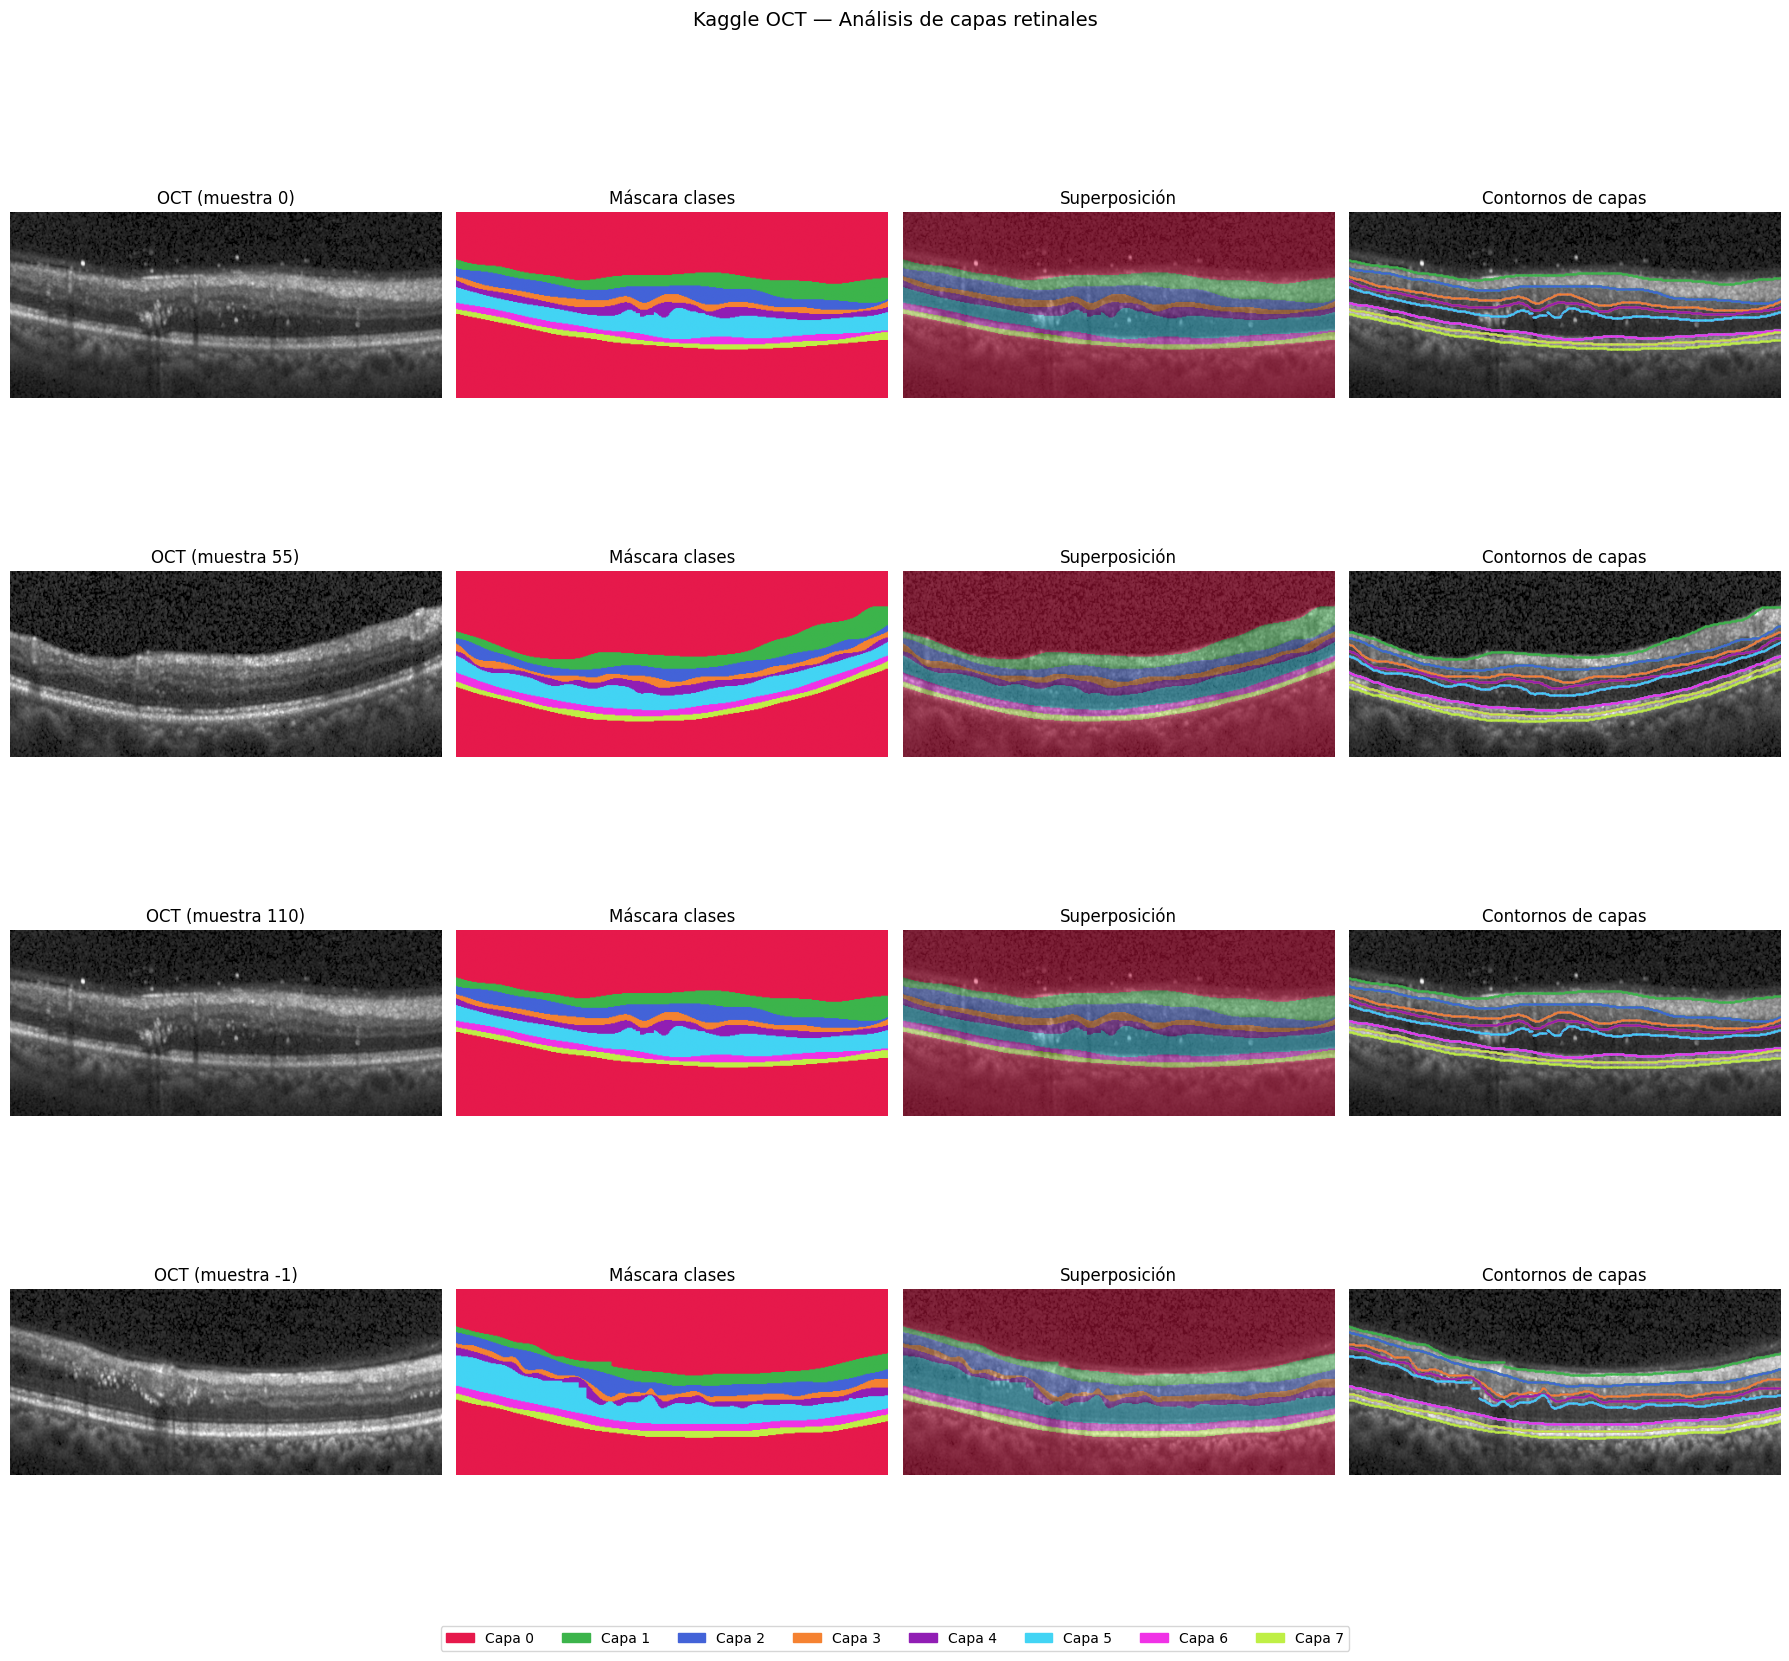

[KAGGLE] Figura de 4 muestras guardada.


In [13]:
# --- Visualización: 4 muestras con imagen + máscara + superposición + capas ---
sample_indices = [0, kag_imgs.shape[0]//4, kag_imgs.shape[0]//2, -1]
cmap_layers = ListedColormap(LAYER_COLORS[:n_classes_kag])

fig, axes = plt.subplots(len(sample_indices), 4, figsize=(18, 4*len(sample_indices)))
fig.suptitle('Kaggle OCT — Análisis de capas retinales', fontsize=14, y=1.01)

for row, idx in enumerate(sample_indices):
    img  = kag_imgs[idx]
    mask = kag_masks[idx]

    # Panel 1: imagen OCT
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'OCT (muestra {idx})')
    axes[row, 0].axis('off')

    # Panel 2: máscara de clases
    im = axes[row, 1].imshow(mask, cmap=cmap_layers, vmin=0, vmax=n_classes_kag-1)
    axes[row, 1].set_title('Máscara clases')
    axes[row, 1].axis('off')

    # Panel 3: superposición
    axes[row, 2].imshow(img, cmap='gray')
    axes[row, 2].imshow(mask, cmap=cmap_layers, alpha=0.45, vmin=0, vmax=n_classes_kag-1)
    axes[row, 2].set_title('Superposición')
    axes[row, 2].axis('off')

    # Panel 4: contornos de capas (boundaries entre clases)
    axes[row, 3].imshow(img, cmap='gray')
    for c in range(1, n_classes_kag):
        boundary = np.where(np.diff((mask == c).astype(np.int8), axis=0))
        axes[row, 3].scatter(boundary[1], boundary[0],
                             s=0.3, color=LAYER_COLORS[c % len(LAYER_COLORS)], label=f'Cap {c}')
    axes[row, 3].set_title('Contornos de capas')
    axes[row, 3].axis('off')

# Leyenda global
patches = [mpatches.Patch(color=LAYER_COLORS[i], label=f'Capa {i}') for i in range(n_classes_kag)]
fig.legend(handles=patches, loc='lower center', ncol=n_classes_kag, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig('kaggle_4samples_layers.png', dpi=120, bbox_inches='tight')
plt.show()
print('[KAGGLE] Figura de 4 muestras guardada.')

---
### Conclusiones EDA
- **Kaggle**: dataset más homogéneo, ya normalizado y con máscara pixel-wise directa.
